In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmc
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
import glob
import os

plt.style.use('../plotstyling.mplstyle')


In [2]:
# --- Load data ---
datetime_str = "20250605023209_20250605041037"
chip_ds = xr.open_dataset(f"../../../DataStorage/AWS/chip-aws-v0.6/chip-aws_{datetime_str}_v0.6.2.nc")
cs_ds   = xr.open_dataset(f"../../../DataStorage/AWS/l2_cloud_signal/l2_cloud_signal_{datetime_str}.nc")

channels       = ["AWS21", "AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]
channels_diffs = ["21-31", "31-32", "32-33", "33-34", "34-35", "35-36", "36-44", "44-43", "43-42", "42-41"]
channel_pairs  = [("AWS33", "AWS44"), ("AWS34", "AWS43"), ("AWS35", "AWS42"), ("AWS36", "AWS41")]


#start, end = 1300, 1700  # interesting case
#start, end = 2300, 3200  # antarctica
#start, end = 1500, 2500

In [3]:
cs_ds

<xarray.Dataset> Size: 186MB
Dimensions:                         (scan: 4963, fov: 88, quantile: 5,
                                     surface_type: 6, channel: 19)
Coordinates:
  * surface_type                    (surface_type) <U7 168B 'ocean' ... 'glac...
    latitude                        (scan, fov) float32 2MB ...
    longitude                       (scan, fov) float32 2MB ...
  * quantile                        (quantile) float32 20B 0.02 0.16 ... 0.98
  * channel                         (channel) <U5 380B 'AWS11' ... 'AWS44'
  * scan                            (scan) datetime64[ns] 40kB 2025-06-05T02:...
Dimensions without coordinates: fov
Data variables: (12/37)
    Ta_CloudSignal_AWS31_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_quantiles  (scan, fov, quantile) float32 9MB ...
    Ta_CloudSignal_AWS32_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_quantiles  (scan, fov, quantile) float32 9MB ...
    ...                              ...
    surface_type_fractions          (scan, fov, surface_type) float32 10MB ...
    tb                              (scan, fov, channel) float32 33MB ...
    model_variant                   (scan, fov) <U8 14MB ...
    l1b_index_scans                 (scan) uint32 20kB ...
    l1b_index_fovs                  (fov) uint32 352B ...
    flag_bad_data                   (scan, fov) uint8 437kB ...
Attributes:
    title:        Retrievals of cloud signal for the Arctic Weather Satellite...
    institution:  Chalmers University of Technology
    references:   n/a
    history:      Retrieval processing

In [4]:
cs_ds.model_variant

<xarray.DataArray 'model_variant' (scan: 4963, fov: 88)> Size: 14MB
[436744 values with dtype=<U8]
Coordinates:
    latitude   (scan, fov) float32 2MB ...
    longitude  (scan, fov) float32 2MB ...
  * scan       (scan) datetime64[ns] 40kB 2025-06-05T02:31:51.570454592 ... 2...
Dimensions without coordinates: fov
Attributes:
    long_name:    Model variant used for retrieval
    description:  Indicates which channel config was used, e.g. aws31_36. Emp...

In [5]:
# some example 'bad' cases in Antarctica

start, end = 2500, 3000

mean_flat_t = cs_ds.Ta_CloudSignal_AWS33_mean.values[start:end].ravel()
q_flat_t    = (cs_ds.Ta_CloudSignal_AWS33_quantiles.values[start:end,:,3] -
               cs_ds.Ta_CloudSignal_AWS33_quantiles.values[start:end,:,1]).ravel()
lat_flat_t  = cs_ds.latitude.values[start:end].ravel()

nan_mask_t  = np.isnan(mean_flat_t)
bad_mask_t  = cs_ds.flag_bad_data.values[start:end].ravel() != 0
valid_t     = ~nan_mask_t & ~bad_mask_t

x_t   = mean_flat_t[valid_t]
y_t   = q_flat_t[valid_t]
lat_t = lat_flat_t[valid_t]

special_mask     = x_t > 50
x_special        = x_t[special_mask]
y_special        = y_t[special_mask]
lat_special      = lat_t[special_mask]
iqr_norm_special = y_special / x_special
print(f"Found {special_mask.sum()} 'bad' points")

Found 52 'bad' points


In [6]:
cs_ds

<xarray.Dataset> Size: 186MB
Dimensions:                         (scan: 4963, fov: 88, quantile: 5,
                                     surface_type: 6, channel: 19)
Coordinates:
  * surface_type                    (surface_type) <U7 168B 'ocean' ... 'glac...
    latitude                        (scan, fov) float32 2MB 72.75 72.82 ... nan
    longitude                       (scan, fov) float32 2MB ...
  * quantile                        (quantile) float32 20B 0.02 0.16 ... 0.98
  * channel                         (channel) <U5 380B 'AWS11' ... 'AWS44'
  * scan                            (scan) datetime64[ns] 40kB 2025-06-05T02:...
Dimensions without coordinates: fov
Data variables: (12/37)
    Ta_CloudSignal_AWS31_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_quantiles  (scan, fov, quantile) float32 9MB ...
    Ta_CloudSignal_AWS32_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_quantiles  (scan, fov, quantile) float32 9MB ...
    ...                              ...
    surface_type_fractions          (scan, fov, surface_type) float32 10MB ...
    tb                              (scan, fov, channel) float32 33MB ...
    model_variant                   (scan, fov) <U8 14MB ...
    l1b_index_scans                 (scan) uint32 20kB ...
    l1b_index_fovs                  (fov) uint32 352B ...
    flag_bad_data                   (scan, fov) uint8 437kB 0 0 0 0 ... 45 45 45
Attributes:
    title:        Retrievals of cloud signal for the Arctic Weather Satellite...
    institution:  Chalmers University of Technology
    references:   n/a
    history:      Retrieval processing

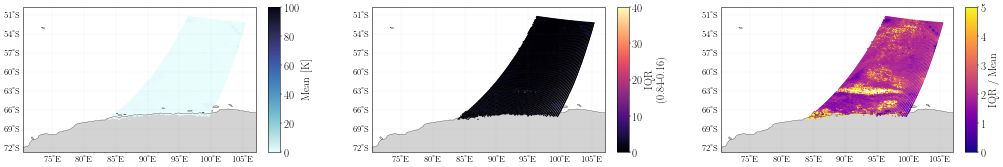

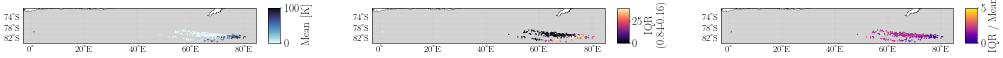

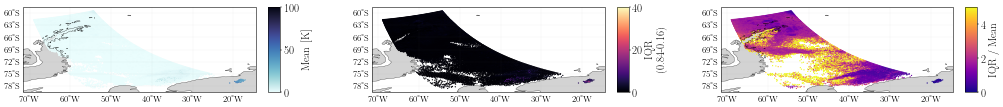

In [7]:
IQR = cs_ds.Ta_CloudSignal_AWS33_quantiles.values[:,:,3] - cs_ds.Ta_CloudSignal_AWS33_quantiles.values[:,:,1]
median = cs_ds.Ta_CloudSignal_AWS33_quantiles.values[:,:,2]
mean = cs_ds.Ta_CloudSignal_AWS33_mean.values

end = 0
for start in range(0, 5000, 300):
    end += 300

    lat_slice = cs_ds.latitude[start:end].values
    if not np.any(lat_slice < -70):
        continue

    nan_mask     = np.isnan(cs_ds.Ta_CloudSignal_AWS33_mean[start:end].values)
    bad_mask     = cs_ds.flag_bad_data[start:end].values != 0
    surface_mask = nan_mask & ~bad_mask

    iqr_slice    = IQR[start:end]
    median_slice = median[start:end]
    mean_slice = mean[start:end]
    
    with np.errstate(invalid='ignore', divide='ignore'):
        iqr_norm_slice = np.where(mean_slice > 0, iqr_slice / mean_slice, np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(30, 12), subplot_kw={"projection": ccrs.PlateCarree()})
    plt.subplots_adjust(wspace=0.5)

    titles = ["Mean [K]", "IQR \n (0.84-0.16)", "IQR / Mean"]
    data   = [mean_slice, iqr_slice, iqr_norm_slice]
    cmaps  = [cmc.cm.ice_r, "magma", "plasma"]
    vmins  = [0, 0, 0]
    vmaxs  = [100, 40, 5]

    for i, (ax, title, d, cmap, vmin, vmax) in enumerate(zip(axes, titles, data, cmaps, vmins, vmaxs)):
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=3)
        ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white",     zorder=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        gl.xlabel_style = gl.ylabel_style = {'size': 16}

        valid = ~surface_mask
        sc = ax.scatter(
            cs_ds.longitude[start:end].values[valid],
            cs_ds.latitude[start:end].values[valid],
            c=d[valid], s=5, vmin=vmin, vmax=vmax, ec="None", zorder=1, cmap=cmap,
        )
        """
        if surface_mask.any() and i == 0:
            ax.scatter(
                cs_ds.longitude[start:end].values[surface_mask],
                cs_ds.latitude[start:end].values[surface_mask],
                c="red", s=5, ec="None", label="Surface impact", zorder=2,
            )
            ax.legend(fontsize=14)
        """
        cax = fig.add_axes([
            ax.get_position().x1 + 0.01,
            ax.get_position().y0,
            0.01,
            ax.get_position().height
        ])
        fig.colorbar(sc, cax=cax, label=title)

    #fig.tight_layout()

    plt.savefig(
        f"../figures/retrievals_on_obs/scenes_with_IQR/IQR_{datetime_str}_{start}_{end}.png",
        dpi=200, bbox_inches="tight", facecolor="white")

In [8]:

files = sorted(glob.glob("../../../DataStorage/AWS/l2_cloud_signal/*.nc"))

x_all   = []
y_all   = []
lat_all = []
lon_all = []

for f in files:

    ds = xr.open_dataset(f)

    mean_flat = ds.Ta_CloudSignal_AWS33_mean.values.ravel()
    q_flat    = (ds.Ta_CloudSignal_AWS33_quantiles.values[:,:,3] -
                 ds.Ta_CloudSignal_AWS33_quantiles.values[:,:,1]).ravel()
    lat_flat  = ds.latitude.values.ravel()
    lon_flat  = ds.longitude.values.ravel()

    nan_mask = np.isnan(mean_flat)
    bad_mask = ds.flag_bad_data.values.ravel() != 0
    valid    = ~nan_mask & ~bad_mask

    x_all.append(mean_flat[valid])
    y_all.append(q_flat[valid])
    lat_all.append(lat_flat[valid])
    lon_all.append(lon_flat[valid])

    ds.close()

x   = np.concatenate(x_all)
y   = np.concatenate(y_all)
lat = np.concatenate(lat_all)
lon = np.concatenate(lon_all)

/tmp/ipykernel_12410/2117547871.py:30: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
/tmp/ipykernel_12410/2117547871.py:30: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
/tmp/ipykernel_12410/2117547871.py:30: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,


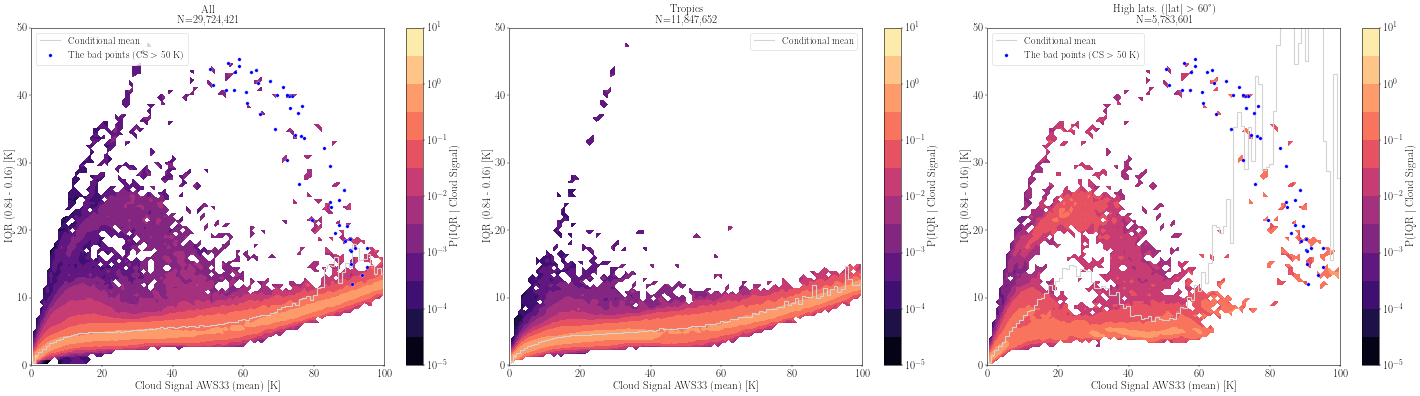

In [11]:
masks = {
    "All"                        : np.ones(len(x), dtype=bool),
    "Tropics"                    : np.abs(lat) < 30,
    "High lats. ($|$lat$|$ $>$ 60°)"  :  np.abs(lat) > 60,
}

xbins = np.linspace(0, 100, 100)
ybins = np.linspace(0, 50, 100)

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

for ax, (label, mask) in zip(axes, masks.items()):
    valid_plot = mask & ~np.isnan(y) & ~np.isnan(x)
    xm, ym = x[valid_plot], y[valid_plot]
    p_joint, xedges, yedges = np.histogram2d(xm, ym, bins=[xbins, ybins], density=True)
    p_cs, _                 = np.histogram(xm, bins=xbins, density=True)
    p_iqr_given_cs          = np.divide(
        p_joint,
        p_cs.reshape(-1, 1),
        out=np.full_like(p_joint, np.nan),
        where=p_cs.reshape(-1, 1) > 0
    )

    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])

    binned_mean = binned_statistic(xm, ym, statistic=np.nanmean, bins=xbins)

    levels = np.logspace(-5, 1, 13)
    cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
                     norm=LogNorm(vmin=1e-5, vmax=1e1), cmap="magma")
    fig.colorbar(cf, ax=ax, label="P(IQR $|$ Cloud Signal)")
    ax.stairs(binned_mean.statistic, binned_mean.bin_edges,
              color="lightgray", lw=2, label="Conditional mean")
    ax.set_xlabel("Cloud Signal AWS33 (mean) [K]")
    ax.set_ylabel("IQR (0.84 - 0.16) [K]")
    ax.set_title(f"{label}\nN={mask.sum():,}")
    #ax.plot(binned_mean.bin_edges, binned_mean.bin_edges)
    ax.set_ylim(ybins[0], ybins[-1])
    ax.set_xlim(xbins[0], xbins[-1])

    if ax != axes[1]:
        ax.scatter(x_special, y_special, c="blue", s=40, zorder=5,
                   ec="white", lw=0.5, label=f"The bad points (CS $>$ 50 K)")
    ax.legend()

#plt.suptitle("P(IQR | Cloud Signal) — AWS33", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/retrievals_on_obs/cloud_signal_vs_IQR_conditional_bylat.png",
            dpi=200, bbox_inches="tight", facecolor="white")

/tmp/ipykernel_12410/363380058.py:29: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
/tmp/ipykernel_12410/363380058.py:29: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
/tmp/ipykernel_12410/363380058.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_12410/363380058.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("../figures/retrievals_on_obs/cloud_signal_vs_IQR_conditional_bylat.png",
/home/eleanor/mambaforge/envs/aws/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


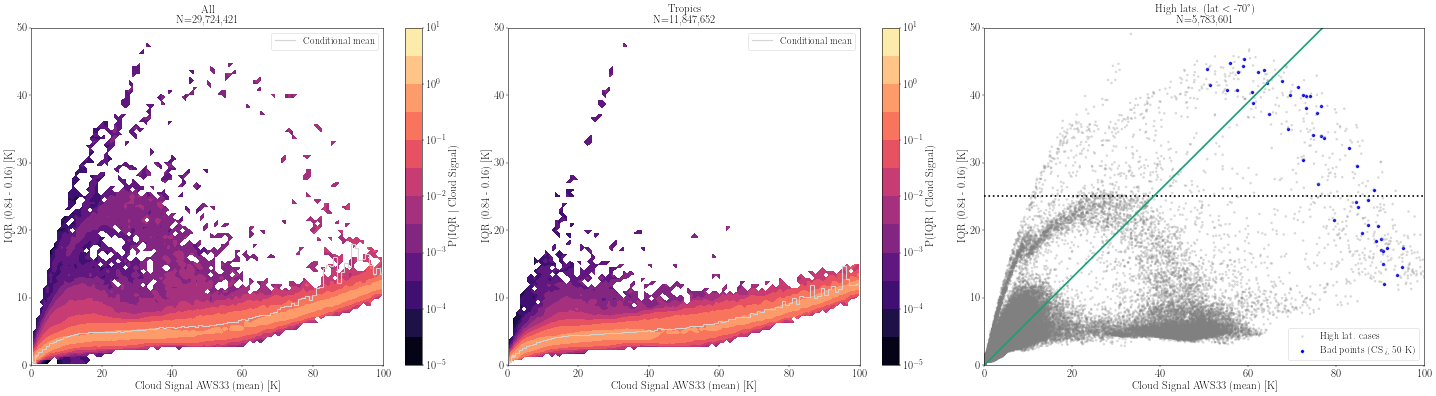

In [10]:
masks = {
    "All"                        : np.ones(len(x), dtype=bool),
    "Tropics"                    : np.abs(lat) < 30,
    "High lats. (lat $<$ -70°)"  :  np.abs(lat) > 60,
}

xbins = np.linspace(0, 100, 100)
ybins = np.linspace(0, 50, 100)

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

for i, (ax, (label, mask)) in enumerate(zip(axes, masks.items())):
    valid_plot = mask & ~np.isnan(y) & ~np.isnan(x)
    xm, ym = x[valid_plot], y[valid_plot]

    if i < 2:
        p_joint, xedges, yedges = np.histogram2d(xm, ym, bins=[xbins, ybins], density=True)
        p_cs, _                 = np.histogram(xm, bins=xbins, density=True)
        p_iqr_given_cs          = np.divide(
            p_joint,
            p_cs.reshape(-1, 1),
            out=np.full_like(p_joint, np.nan),
            where=p_cs.reshape(-1, 1) > 0
        )
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        binned_mean = binned_statistic(xm, ym, statistic=np.nanmean, bins=xbins)
        levels = np.logspace(-5, 1, 13)
        cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
                         norm=LogNorm(vmin=1e-5, vmax=1e1), cmap="magma")
        fig.colorbar(cf, ax=ax, label="P(IQR $|$ Cloud Signal)")
        ax.stairs(binned_mean.statistic, binned_mean.bin_edges,
                  color="lightgray", lw=2, label="Conditional mean")
    else:
        ax.scatter(xm, ym, c="gray", s=20, alpha=0.3, ec="none", zorder=1, label="High lat. cases")

    if i == 2:
        ax.scatter(x_special, y_special, c="blue", s=40, zorder=0,
               ec="white", lw=0.5, label="Bad points (CS > 50 K)")
        ax.axhline(25, c="k", ls=":")
        ax.plot(binned_mean.bin_edges, 0.65*binned_mean.bin_edges)
    ax.set_xlabel("Cloud Signal AWS33 (mean) [K]")
    ax.set_ylabel("IQR (0.84 - 0.16) [K]")
    ax.set_title(f"{label}\nN={mask.sum():,}")
    ax.set_ylim(ybins[0], ybins[-1])
    ax.set_xlim(xbins[0], xbins[-1])
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/retrievals_on_obs/cloud_signal_vs_IQR_conditional_bylat.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
with np.errstate(invalid='ignore', divide='ignore'):
    iqr_norm = np.where(x > 0, y / x, np.nan)

masks = {
    "All"                     : np.ones(len(x), dtype=bool),
    "Tropics (|lat| < 30°)"   : np.abs(lat) < 30,
    "High lat. (|lat| > 60°)" : np.abs(lat) > 60,
}

xbins = np.linspace(0, 100, 100)
ybins = np.linspace(0, 30, 100)

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

for ax, (label, mask) in zip(axes, masks.items()):
    xm = x[mask]
    ym = iqr_norm[mask]
    ym = ym[~np.isnan(ym)]
    xm = xm[~np.isnan(iqr_norm[mask])]

    p_joint, xedges, yedges = np.histogram2d(xm, ym, bins=[xbins, ybins], density=True)
    p_cs, _                 = np.histogram(xm, bins=xbins, density=True)
    p_iqr_given_cs          = np.divide(
        p_joint,
        p_cs.reshape(-1, 1),
        out=np.full_like(p_joint, np.nan),
        where=p_cs.reshape(-1, 1) > 0
    )

    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])

    binned_mean = binned_statistic(xm, ym, statistic=np.nanmean, bins=xbins)

    levels = np.logspace(-3, 1, 17)
    cf = ax.contourf(xc, yc, p_iqr_given_cs.T, levels=levels,
                     norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="magma")
    fig.colorbar(cf, ax=ax, label="P(IQR/mean | Cloud Signal)")
    ax.stairs(binned_mean.statistic, binned_mean.bin_edges,
              color="lightgray", lw=2, label="Conditional mean")

    ax.scatter(x_special, iqr_norm_special, c="blue", s=40, zorder=5,
               ec="white", lw=0.5, label=f"Special points (CS > 50 K)")

    ax.set_xlabel("Cloud Signal AWS33 (mean) [K]")
    ax.set_ylabel("IQR / mean")
    ax.set_xlim(xbins[0], xbins[-1])
    ax.set_ylim(ybins[0], ybins[-1])
    ax.set_title(f"{label}\nN={mask.sum():,}")
    ax.legend()

plt.suptitle("P(IQR/mean | Cloud Signal) — AWS33", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/retrievals_on_obs/cloud_signal_vs_IQRnorm_conditional_bylat.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
# --- define regions ---
lat_mask = np.abs(lat) > 60
mask_a = lat_mask & (x > 10)  & (y > 27)
mask_b = lat_mask & (x > 20)  & (y > 0.65 * x) & (y < 27)
mask_c = lat_mask & (x > 30)  & (y < 8)
region_colors = ["crimson", "gold", "dodgerblue"]
region_labels = [
    r"CS $>$ 10 K, IQR $>$ 25 K",
    r"CS $>$ 30 K, IQR $<$ 8 K",
    r"CS $>$ 20 K, IQR $>$ 0.65·CS",
]
region_masks = [mask_a, mask_c, mask_b]

with np.errstate(invalid='ignore', divide='ignore'):
    iqr_norm = np.where(x > 0, y / x, np.nan)

fig = plt.figure(figsize=(40, 10))
gs  = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], hspace=0.05, wspace=0.1)

ax_north = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_south = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax_sc    = fig.add_subplot(gs[:, 1])
ax_sc2   = fig.add_subplot(gs[:, 2])

for ax, extent, title in zip(
    [ax_north, ax_south],
    [[-180, 180, 60, 90], [-180, 180, -90, -60]],
    ["Arctic (lat > 60°)", "Antarctic (lat < -60°)"],
):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=3)
    ax.add_feature(cfeature.LAND,      facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor="white",     zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 12}
    ax.set_extent(extent)
    for mask, color, label in zip(region_masks, region_colors, region_labels):
        ax.scatter(lon[mask], lat[mask], c=color, s=2, ec="none",
                   zorder=2, alpha=0.5, label=label)
    ax.set_title(title)

ax_north.legend(markerscale=6)

# --- CS vs IQR ---
valid_plot = (np.abs(lat) > 60) & ~np.isnan(y) & ~np.isnan(x)
ax_sc.scatter(x[valid_plot], y[valid_plot],
              c="gray", s=20, alpha=0.2, ec="none", zorder=1, label="High lat. cases")
for mask, color, label in zip(region_masks, region_colors, region_labels):
    ax_sc.scatter(x[mask & valid_plot], y[mask & valid_plot],
                  c=color, s=20, ec="none", zorder=3, alpha=0.6, label=label)
xlim = np.linspace(0, 100, 200)
ax_sc.axhline(27,           c="crimson",    ls="--", lw=1, alpha=0.7)
ax_sc.plot(xlim, 0.65*xlim, c="dodgerblue", ls="--", lw=1, alpha=0.7)
ax_sc.axhline(8,            c="gold",       ls="--", lw=1, alpha=0.7)
ax_sc.set_xlabel("Cloud Signal AWS33 (mean) [K]")
ax_sc.set_ylabel("IQR (0.84 - 0.16) [K]")
ax_sc.set_xlim(0, 100)
ax_sc.set_ylim(0, 50)
ax_sc.set_title("CS vs IQR — high lats.")
ax_sc.legend(markerscale=2)

# --- CS vs IQR/mean ---
valid_plot2 = valid_plot & ~np.isnan(iqr_norm)
ax_sc2.scatter(x[valid_plot2], iqr_norm[valid_plot2],
               c="gray", s=20, alpha=0.2, ec="none", zorder=1, label="High lat. cases")
for mask, color, label in zip(region_masks, region_colors, region_labels):
    ax_sc2.scatter(x[mask & valid_plot2], iqr_norm[mask & valid_plot2],
                   c=color, s=20, ec="none", zorder=3, alpha=0.6, label=label)
ax_sc2.set_xlabel("Cloud Signal AWS33 (mean) [K]")
ax_sc2.set_ylabel("IQR / mean")
ax_sc2.set_xlim(0, 100)
ax_sc2.set_ylim(0, 10)
ax_sc2.set_title("CS vs IQR/mean — high lats.")
ax_sc2.legend(markerscale=2)

plt.savefig("../figures/retrievals_on_obs/world_map_and_scatter_regions_high_lats.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

ax.plot(np.array([0.02, 0.16, 0.5, 0.84, 0.98]), AWS33_quantiles_issue_cases.T, c="red", alpha=0.2)
#for i in range(10):
#    ax.axhline(AWS33_issue_cases[i])

ax.plot(np.array([0.02, 0.16, 0.5, 0.84, 0.98]), AWS33_mean_quantiles, c="k", ls="-")

#ax.set_ylim([-5,5])
ax.set_ylabel("Cloud signal [K]")
ax.set_xlabel("Quantile")

In [ ]:
AWS33_quantiles_issue_cases

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

ax.plot(np.array([0.02, 0.16, 0.5, 0.84, 0.98]), AWS33_quantiles_issue_cases.T, c="red", alpha=0.2)
#for i in range(10):
#    ax.axhline(AWS33_issue_cases[i])

ax.plot(np.array([0.02, 0.16, 0.5, 0.84, 0.98]), AWS33_mean_quantiles, c="k", ls="-")

ax.set_ylim([-5,5])
ax.set_ylabel("Cloud signal [K]")
ax.set_xlabel("Quantile")

In [ ]:
cs_ds

In [ ]:
AWS35_quantiles_issue_cases.shape

In [ ]:
# --- Extract matching chip_ds cases ---
scan_rel_idxs, fov_idxs = np.where(surface_mask)
matching_scans     = cs_ds.scan[start:end].values[scan_rel_idxs]
matching_chip_idxs = np.searchsorted(chip_ds.scan.values, matching_scans)

surface_cases = chip_ds.isel(
    scan=xr.DataArray(matching_chip_idxs, dims="points"),
    fov =xr.DataArray(fov_idxs,           dims="points"),
)
print(f"Found {surface_mask.sum()} surface-impact cases")

# --- Prepare arrays ---
tb = surface_cases.tb.sel(channel=channels).values  # (points, 11), reordered

dTb_data = np.stack([
    (surface_cases.tb.sel(channel=a) - surface_cases.tb.sel(channel=b)).values
    for a, b in channel_pairs
], axis=1)  # (points, 4)

pair_labels = [f"{a[3:]}−{b[3:]}" for a, b in channel_pairs]  # e.g. "33−44"

# --- Prepare full-dataset arrays ---
tb_all = chip_ds.tb.sel(channel=channels).values.reshape(-1, 11)  # (all_points, 11)

dTb_all = np.stack([
    (chip_ds.tb.sel(channel=a) - chip_ds.tb.sel(channel=b)).values.ravel()
    for a, b in channel_pairs
], axis=1)  # (all_points, 4)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

plot_configs = [
    {"data": tb,       "data_all": tb_all,  "x": np.arange(11), "ylabel": r"T$_{b}$ [K]",         "xticklabels": channels,       "diff": False},
    {"data": tb,       "data_all": tb_all,  "x": np.arange(10), "ylabel": r"$\Delta$T$_{b}$ [K]", "xticklabels": channels_diffs, "diff": True },
    {"data": dTb_data, "data_all": dTb_all, "x": np.arange(4),  "ylabel": r"$\Delta$T$_{b}$ [K]", "xticklabels": pair_labels,    "diff": False},
]

for ax, cfg in zip(axes, plot_configs):
    d     = -1 * np.diff(cfg["data"])     if cfg["diff"] else cfg["data"]
    d_all = -1 * np.diff(cfg["data_all"]) if cfg["diff"] else cfg["data_all"]
    x = cfg["x"]

    # Background: full dataset in grey
    bg_kw = dict(c="grey", zorder=1)
    ax.plot(x, np.mean(d_all, axis=0),               label="All obs", **bg_kw)
    ax.plot(x, np.percentile(d_all, 25, axis=0), "--", **bg_kw)
    ax.plot(x, np.percentile(d_all, 75, axis=0), "--", **bg_kw)
    ax.plot(x, np.percentile(d_all,  1, axis=0), ":",  **bg_kw)
    ax.plot(x, np.percentile(d_all, 99, axis=0), ":",  **bg_kw)

    # Foreground: individual spectra for each case
    for i, spectrum in enumerate(d):
        ax.plot(x, spectrum, c="firebrick", alpha=0.5, linewidth=0.8,
                label="Surface-impact cases" if i == 0 else None, zorder=2)

    ax.legend(ncols=2)
    ax.set_xticks(x)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(cfg["xticklabels"])
    ax.set_ylabel(cfg["ylabel"])
    ax.grid()
    ax.set_title("Possible DC cases in retrievals", loc="left")

plt.tight_layout()
plt.savefig(
    f"../figures/deep_convection/DC_in_retrievals_{datetime_str}.png",
    dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
dTb_36_44 = chip_ds.tb.sel(channel="AWS36").values - chip_ds.tb.sel(channel="AWS44").values
dTb_35_33 = chip_ds.tb.sel(channel="AWS35").values - chip_ds.tb.sel(channel="AWS33").values
dTb_35_34 = chip_ds.tb.sel(channel="AWS35").values - chip_ds.tb.sel(channel="AWS34").values
dTb_34_33 = chip_ds.tb.sel(channel="AWS34").values - chip_ds.tb.sel(channel="AWS33").values

Ta_3336 = chip_ds.tb.sel(channel=["AWS33", "AWS34", "AWS35", "AWS36"]).values  # (points, 4)

combined_condition = (
    (dTb_36_44 > 0) &
    (np.abs(dTb_35_33) >= np.abs(dTb_35_34)) &
    (np.abs(dTb_35_34) >= np.abs(dTb_34_33)) &
    (np.abs(dTb_34_33) >= 0)
)

std_condition = (
    (Ta_3336.std(axis=-1) < 1)
    & (dTb_36_44 > 20)
)

threshold = 2 # K

flat_condition = (
    (np.abs(dTb_34_33) < threshold) &
    (np.abs(dTb_35_34) < threshold) &
    (np.abs(dTb_35_33) < threshold * 2)  # end-to-end as a sanity check
)

scan_idxs, fov_idxs = np.where(std_condition)
scan_indexer = xr.DataArray(scan_idxs, dims="points")
fov_indexer  = xr.DataArray(fov_idxs,  dims="points")
high_36_44_cases = chip_ds.isel(scan=scan_indexer, fov=fov_indexer)

print(f"Found {combined_condition.sum()} cases")

In [ ]:
# --- Map ---
fig, ax = plt.subplots(1, 1, figsize=(24, 12), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=3)
ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white",     zorder=0)
gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 16}

ax.scatter(chip_ds.longitude.values[scan_idxs, fov_idxs],
           chip_ds.latitude.values[scan_idxs, fov_idxs],
          s=3, c='red')


In [ ]:
Ta_3336 = surface_cases.tb.sel(channel=["AWS33", "AWS34", "AWS35", "AWS36"]).values  # (points, 4)
dTb_34_33 = surface_cases.tb.sel(channel="AWS34").values - surface_cases.tb.sel(channel="AWS33").values
dTb_36_44 = surface_cases.tb.sel(channel="AWS36").values - surface_cases.tb.sel(channel="AWS44").values
dTb_35_33 = surface_cases.tb.sel(channel="AWS35").values - surface_cases.tb.sel(channel="AWS33").values
dTb_35_34 = surface_cases.tb.sel(channel="AWS35").values - surface_cases.tb.sel(channel="AWS34").values
dTb_34_33 = surface_cases.tb.sel(channel="AWS34").values - surface_cases.tb.sel(channel="AWS33").values

combined_condition = (
    (dTb_36_44 > 0) &
    (np.abs(dTb_35_33) >= np.abs(dTb_35_34)) &
    (np.abs(dTb_35_34) >= np.abs(dTb_34_33)) &
    (np.abs(dTb_34_33) >= 0)
)

std_condition = (
    (Ta_3336.std(axis=-1) < 1)
    & (dTb_36_44 > 20)
)

threshold = 2 # K

flat_condition = (
    (np.abs(dTb_34_33) < threshold) &
    (np.abs(dTb_35_34) < threshold) &
    (np.abs(dTb_35_33) < threshold * 2)  # end-to-end as a sanity check
)

flat_cases = surface_cases.isel(points=np.where(combined_condition)[0])
print(f"Found {combined_condition.sum()} flat cases")

In [ ]:
surface_cases.l1b_index_fovs.values

In [ ]:
surface_cases.remap_distance.values